# Retrieval

In [1]:
import numpy as np # Used for return type and embeddings .
import open_clip # Used to load image embedding model  .
import torch # Used for device handling and tensor operations .
import os # Used for locating database storage .
from sentence_transformers import SentenceTransformer # Used to load text embedding model .
import chromadb # Used for vectorDB operations .
from typing import Dict # Used for datatype handling .

In [2]:
# Used image embedding and query embedding .
class OpenClipTextEmbeddingModel:
     def __init__(self,model_name:str="ViT-B-32",pretrained:str="laion2b_s34b_b79k"):

        self.device="cuda" if torch.cuda.is_available() else "cpu" # Used to check if the machine has GPU if not assign CPU as device for working .
        self.model,self.preprocess,_=open_clip.create_model_and_transforms(
            model_name=model_name,
            pretrained=pretrained
        ) # Getting essential function from model .
        self.tokenizer=open_clip.get_tokenizer(model_name)
        self.model=self.model.to(self.device) # Device selection for model operations .
        self.model.eval() # Loading model

        # Displaying device on which model will run .
        if self.device=="cuda":
            print(f"OpenClip running on {torch.cuda.get_device_name(0)} .")
        else:
            print("OpenClip running on CPU .")
        print(f"Embedding dimensions of {model_name} is {open_clip.get_model_config(model_name).get('embed_dim')}")

     @torch.no_grad()
     def embed_query(self,query:str)->np.ndarray:
         if not query.strip():
             raise ValueError("Please give a valid prompt .")

         tokens=self.tokenizer([query]).to(self.device) # Used to convert into tensor .
         query_embedding=self.model.encode_text(tokens) # Embedding text or tensor value .
         query_embedding=query_embedding/query_embedding.norm(dim=-1,keepdim=True) # Normalizing values
         query_embedding=query_embedding.cpu().numpy()[0] # Converting tensor to numpy array .

         return query_embedding # Returning all the embeddings .

In [3]:
image_model=OpenClipTextEmbeddingModel()

OpenClip running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Embedding dimensions of ViT-B-32 is 512


In [4]:
# Used for text embedding and query embedding .
class BGETextEmbeddingModel:

    def __init__(self,model_name:str= "BAAI/bge-base-en-v1.5"):
        self.device="cuda" if torch.cuda.is_available() else "cpu" # Device check .
        self.model=SentenceTransformer(model_name_or_path=model_name,device=self.device) # Loading model .
        self.query_prefix="Represent this sentence for searching relevant passages: "
        if self.device=="cuda":
            print(f"BGE running on {torch.cuda.get_device_name(0)} .")
        else:
            print("BGE running on CPU .")
        print(f"Dimension of {model_name} is {self.model.get_sentence_embedding_dimension()}")

    @torch.no_grad()
    def embed_query(self,query:str)->np.ndarray:

        if not query.strip():
            raise ValueError("Given prompt is not valid .")

        query=self.query_prefix + query # Adding a prefix to prompt since BGE is instruction based embedding model .(Only for prompt not mandatory for documents)

        query_embedding=self.model.encode( # Embedding query .
            sentences=query,
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        return query_embedding # Returning embedded values .

In [5]:
text_model=BGETextEmbeddingModel()

BGE running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Dimension of BAAI/bge-base-en-v1.5 is 768


In [6]:
class VectorStore:
    def __init__(self,collection_name:str,directory:str="../data/database"):
        self.collection_name=collection_name # Collection name .
        self.persistent_directory=directory # Directory to store database .
        self.collection=None # Collection , used to store data .
        self.client=None # Used to connect database .
        self.initialize_store() # Initializing vectordb .

    def initialize_store(self):
            try:
                os.makedirs(name=self.persistent_directory,exist_ok=True) # Checking if directory exists ,if not creating one .
                self.client=chromadb.PersistentClient(path=self.persistent_directory)

                if self.collection_exists(self.collection_name): # Checking if the collection exists , if collection exists then loading it .
                    print(f"Loading collection {self.collection_name} from database .")
                    self.collection=self.client.get_collection(self.collection_name)

                else: # If collection does not exist then creating it .
                    print(f"New collection {self.collection_name} created in database .")
                    self.collection=self.client.create_collection(self.collection_name)

                print(f"Vector store initialized .") # Success message is vector store initialized .
                print(f"Existing documents in collection {self.collection.count()}")

            except Exception as e: # Exception handling .
                raise RuntimeError("Could not initialize vector store .") from e
    # The following function is used to check if the collection exists .
    def collection_exists(self,collection_name:str)->bool:
        collection_in_db=self.client.list_collections()
        return any(col.name==collection_name for col in collection_in_db )

    # The following function is used get queries and get relevant documents
    def query(self,query_embedding:np.ndarray,k:int=5,where:Dict | None=None):

        if not self.collection: # Checking if collection is initialized .
            raise RuntimeError("Collection is not initialized .")

        if query_embedding.ndim!=1: # Checking if query is single dimension .
            raise ValueError("Query embedding must be a 1D vector .")

        results=self.collection.query( # Embedding query .
            query_embeddings=[query_embedding.tolist()],
            n_results=k,
            where=where,
            include=["documents","metadatas","distances"]
        )
        return results # Returning results .

In [7]:
Image_vector_store=VectorStore(collection_name="OpenClip_embeddings") # Using existing data from database .

Loading collection OpenClip_embeddings from database .
Vector store initialized .
Existing documents in collection 130


In [8]:
Text_vector_store=VectorStore(collection_name="BGE_embeddings") # Using existing data from database .

Loading collection BGE_embeddings from database .
Vector store initialized .
Existing documents in collection 161


In [9]:
# Used to retrieve documents from database using input query from user .
class RetrievalRag:

    def __init__(self,open_clip_embedding:OpenClipTextEmbeddingModel,bge_embedding:BGETextEmbeddingModel,image_vectordb:VectorStore,text_vectordb:VectorStore):

        if not isinstance(open_clip_embedding, OpenClipTextEmbeddingModel):
            raise TypeError("open_clip_embedding must be an instance of ImageEmbeddingModel")
        if not isinstance(bge_embedding, BGETextEmbeddingModel):
            raise TypeError("bge_embedding must be an instance of TextEmbeddingModel")
        if not isinstance(image_vectordb, VectorStore):
            raise TypeError("image_vectordb must be an instance of VectorStore")
        if not isinstance(text_vectordb, VectorStore):
            raise TypeError("text_vectordb must be an instance of VectorStore")

        self.open_clip_embedding=open_clip_embedding # Image embedding model .
        self.bge_embedding=bge_embedding # Text embedding model .
        self.image_vectordb=image_vectordb # Image database .
        self.text_vectordb=text_vectordb # Text database .

    # Note : We are embedding query from the embedding models used to embed the data in database since the dimensions of the both query and data must be same to do a semantic search .
    # The following function is used to retrieve text from database .
    def retrieve_text(self,query:str,k:int=5)->Dict:
        if not query or not query.strip(): # Query validation .
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        query_embedding=self.bge_embedding.embed_query(query) # Embedding query .

        results=self.text_vectordb.query(query_embedding=query_embedding,k=k)

        return results # Returning top k results .

    # The following function is used to retrieve images and its caption from database .
    def retrieve_images(self,query:str,k:int=3)->Dict:
        if not query or not query.strip(): # Query validation .
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        query_embedding=self.open_clip_embedding.embed_query(query) # Embedding query .

        results=self.image_vectordb.query(
            query_embedding=query_embedding,k=k
        )

        return results

    # Used to retrieve
    def retrieve(self,query:str,text_k:int=5,image_k:int=3)->Dict:
        if not query or not query.strip(): # Checking if query is valid .
            raise ValueError("Query must be non-empty string .")

        if not isinstance(text_k, int) or text_k <= 0: # Threshold validation .
            raise ValueError(f"text_k must be a positive integer, got {text_k}.")

        if not isinstance(image_k, int) or image_k <= 0:
            raise ValueError(f"image_k must be a positive integer, got {image_k}.")

        text_results=self.retrieve_text(query=query,k=text_k)
        image_results=self.retrieve_images(query=query,k=image_k)

        return { # Returning retrieved documents from database .
            "query":query,
            "text_results":text_results,
            "image_results":image_results
        }

In [10]:
retrieval=RetrievalRag(open_clip_embedding=image_model,bge_embedding=text_model,image_vectordb=Image_vector_store,text_vectordb=Text_vector_store) # Initializing required variables .

In [11]:
retrieved_docs = retrieval.retrieve("What does the Hubble–James Webb comparison image of NGC 5468 reveal?") # Test question .

In [12]:
print(retrieved_docs.keys()) # Getting output keys .

dict_keys(['query', 'text_results', 'image_results'])


In [13]:
print(retrieved_docs)

{'query': 'What does the Hubble–James Webb comparison image of NGC 5468 reveal?', 'text_results': {'ids': [['dcc583e88fdaaf95dc951bb0c632bbc2f14c9a2726dfab6d9a9963db522eed49', '5adcbe5e77f34a2ba72b89397340f9a21c1aedfc534aa3838cb67b8843835669', '256fd7daaec61078dca14a5a66f12405b6f3e652af83dff2769224b371580842', '6215f6b9d552c844aca747c52ca79bc64978b0eac421c195f6dce44c2f2537fa', '6c9513c5d472d23b9e065be98e15ebd376d899c0b2977a647ccbd783b1a1006f']], 'embeddings': None, 'documents': [['In April 2020, astronomers discovered a supernova inside the interacting \nButterfly galaxies (NGC 4568). They quickly trained Hubble on the aftermath \nand got a ringside view of the supernova in the very earliest stage of \nexploding. Hubble viewed a region very close to the supernova, examining \nmaterial ejected by the star in the last year of its life. These observations \nmay provide astronomers with an early warning system for other stars on \nthe brink of an explosive death.', 'filaments, the astronom

In [14]:
from PIL import Image
import os
from typing import List,Dict,Optional

In [15]:
# Used to format retrieved docs from retrieval output .
class ContextFormatter:

    def __init__(self,max_text_chunks:int=3,max_images:int=1,text_distance_threshold:float=0.65,image_distance_threshold:float=0.95):
        if not isinstance(max_text_chunks, int) or max_text_chunks <= 0: # Threshold value validation .
            raise ValueError(f"max_text_chunks must be a positive integer, got {max_text_chunks}.")

        if not isinstance(max_images, int) or max_images <= 0:
            raise ValueError(f"max_images must be a positive integer, got {max_images}.")

        if not isinstance(text_distance_threshold, (int, float)) or text_distance_threshold < 0:
            raise ValueError(f"text_distance_threshold must be a non-negative number, got {text_distance_threshold}.")

        if not isinstance(image_distance_threshold, (int, float)) or image_distance_threshold < 0:
            raise ValueError(f"image_distance_threshold must be a non-negative number, got {image_distance_threshold}.")

        self.max_text_chunks=max_text_chunks # Limiting number of chunks .
        self.max_images=max_images # Limiting number of max images .
        self.text_distance_threshold=float(text_distance_threshold) # Threshold for filtering chunks .
        self.image_distance_threshold=float(image_distance_threshold) # Threshold for filtering images .

    # Removing unwanted details from results .
    def _flatten_results(self,results:Dict)->List[Dict]:

        if not results or not isinstance(results,dict): # Checking if data is empty .
            return []

        documents=results.get("documents",[[]])[0]
        metadatas=results.get("metadatas",[[]])[0]
        distances=results.get("distances",[[]])[0]

        documents = results.get("documents", [[]])
        metadatas = results.get("metadatas", [[]])
        distances = results.get("distances", [[]])

        # Check if we have valid nested lists .
        if not documents or not isinstance(documents, list) or len(documents) == 0:
            return []

        docs = documents[0] if len(documents) > 0 else []
        metas = metadatas[0] if len(metadatas) > 0 else []
        dists = distances[0] if len(distances) > 0 else []

        # Ensure all lists have the same length .
        min_length = min(len(docs), len(metas), len(dists))
        if min_length == 0:
            return []

        flattened=[]
        for i in range(min_length):
            flattened.append({ # Appending required data .
                "text":docs[i],
                "metadata":metas[i],
                "distance":float(dists[i])
            })

        return flattened # Returning flattened data .

    # The following function is used to load image from path .
    def _load_image(self,image_path:str) -> Optional[Image.Image]:

        if not image_path or not isinstance(image_path, str): # Checking is image path is valid .
            return None

        if not os.path.exists(image_path):
            print(f"Warning: Image path does not exist: {image_path}")
            return None

        try:
            return Image.open(image_path).convert("RGB") # Returning loaded image .
        except Exception as e:
            print(f"Failed to load image {image_path}: {e}")
            return None

    # The following function is filter text chunks based on distance .
    def _select_text_chunks(self,text_results:Dict)->List[Dict]:
        items=self._flatten_results(text_results) # Removing unwanted data from results .

        if not items: # Checking if items is empty .
            return []

        filtered=[
            i for i in items
            if i["distance"] <= self.text_distance_threshold # Filtering based on distance .
        ]

        if not filtered: # If there is no chunks (All the chunks distance greater than threshold) just return retrieved chunks .

            items.sort(key=lambda x:x["distance"])
            return items[: self.max_text_chunks] # Returning max number of chunks .

        filtered.sort(key=lambda x:x["distance"])

        return filtered[: self.max_text_chunks] # Returning filtered chunks .

    # The following function is to format text in a data .
    def _format_text_context(self,text_items:List[Dict])->str:
        if not text_items or not isinstance(text_items, list): # Input validation .
            return ""

        lines=[]

        for idx,item in enumerate(text_items,start=1): # Fetching required data .
            if not isinstance(item, dict):
                continue

            meta=item["metadata"] or {}
            source=meta.get("source","unknown")
            page=meta.get("page_num","N/A")

            text=item["text"].strip()

            if not text:
                continue

            lines.append(
                f"[{idx}] {text}\n"
                f"(Source: {source}, page {page})" # Attaching source and page number .
            )

        return "\n\n".join(lines) # Returning formatted text .

    # The following function is select images from retrieved output .
    def _select_images(self,image_results:Dict)->List[Dict]:
        items=self._flatten_results(image_results) # Removing unwanted data from results .

        if not items:
            return []

        items=[
            i for i in items
            if i["distance"] <= self.image_distance_threshold # Filtering based on distance .
        ]

        items.sort(key=lambda x: x["distance"])

        return items[: self.max_images] # Returning filtered output .

    # The following function is used to format image caption .
    def _format_image_context(self,image_items:List[Dict])->List[Dict]:

        if not image_items or not isinstance(image_items, list):
            return []

        formatted_images=[]

        for item in image_items: # Fetching required data .
            if not isinstance(item, dict):
                continue

            meta=item.get("metadata") or {}
            image_path=meta.get("image_path")
            caption=meta.get("caption_text", "").strip()

            image=self._load_image(image_path) # Loading image .
            if image is None: # Checking if image is not empty .
                continue

            formatted_images.append({ # Attaching image and its caption .
                "image":image,
                "caption":caption
            })

        return formatted_images # Returning formatted images .

    # The following function is to format both text and images .
    def format(self,retrieval_output:Dict)->Dict:
        if not retrieval_output or not isinstance(retrieval_output, dict):
            raise ValueError("retrieval_output must be a non-empty dictionary.")

        query=retrieval_output.get("query", "") # Fetching query .

        text_items=self._select_text_chunks(
            retrieval_output.get("text_results",{}) # Selecting text chunks .
        )

        image_items=self._select_images(
            retrieval_output.get("image_results",{}) # Selecting images .
        )

        return { # Returning filtered text and images .
            "query":query,
            "text_context":self._format_text_context(text_items),
            "images":self._format_image_context(image_items)
        }

In [16]:
formatter=ContextFormatter() # Initializing context formatter .

In [17]:
# Test questions .
TEST_QUESTIONS = [
    {
        "id": 1,
        "question": "Using Hubble’s long-term observations of Jupiter, explain how astronomers determined that the shrinking of the Great Red Spot is a real atmospheric change rather than an observational artifact.",
        "expected_images": False
    },
    {
        "id": 2,
        "question": "What observational evidence from Hubble images supports the conclusion that the breakup of asteroid P/2013 R3 was not caused by a collision?",
        "expected_images": True
    },
    {
        "id": 3,
        "question": "How did multi-wavelength observations (ultraviolet, visible, infrared) allow Hubble to uncover hidden stages of star formation inside dense nebulae?",
        "expected_images": False
    },
    {
        "id": 4,
        "question": "Why were light echo images, such as those of V838 Monocerotis, crucial for distinguishing between physical expansion of matter and the propagation of light through surrounding dust?",
        "expected_images": True
    },
    {
        "id": 5,
        "question": "Explain how Hubble observations of Cepheid variable stars and Type Ia supernovae together strengthened the cosmic distance ladder.",
        "expected_images": False
    },
    {
        "id": 6,
        "question": "Which visual characteristics in Hubble images indicate the presence of gravitational lensing, and why are these features essential for studying very distant galaxies?",
        "expected_images": True
    },
    {
        "id": 7,
        "question": "How did Hubble’s observations of galaxy mergers change earlier assumptions that galaxies evolve in isolation?",
        "expected_images": False
    },
    {
        "id": 8,
        "question": "What specific visual evidence from Hubble images supports the conclusion that supermassive black holes exist at the centers of most galaxies?",
        "expected_images": True
    },
    {
        "id": 9,
        "question": "Why are visually striking planetary nebula images scientifically important for understanding stellar death, even though they are not used for distance measurements?",
        "expected_images": False
    },
    {
        "id": 10,
        "question": "Using both visual (gravitational lensing maps) and non-visual evidence (galaxy motion and clustering), explain how Hubble helped infer the large-scale distribution of dark matter in the universe.",
        "expected_images": "optional"
    }
]

In [18]:
from typing import List, Dict

In [19]:
def retrieve_test_questions(retrieval, test_questions: List[Dict]) -> List[Dict]:
    """Retrieve outputs for test questions."""
    if not test_questions:
        raise ValueError("test_questions list is empty.")

    retrieval_output = []

    print(f"Processing {len(test_questions)} test questions...")

    for idx, question_data in enumerate(test_questions, start=1):
        if not isinstance(question_data, dict):
            print(f"Warning: Skipping invalid question data at index {idx}")
            continue

        question_id = question_data.get("id", f"unknown_{idx}")
        question_text = question_data.get("question", "")
        expected_images = question_data.get("expected_images", [])

        if not question_text:
            print(f"Warning: Skipping question {question_id} - no question text")
            continue

        try:
            print(f"[{idx}/{len(test_questions)}] Processing question: {question_id}")
            result = retrieval.retrieve(question_text)

            retrieval_output.append({
                "id": question_id,
                "question": question_text,
                "expected_images": expected_images,
                "result": result
            })

        except Exception as e:
            print(f"Error processing question {question_id}: {e}")
            continue

    print(f"\nSuccessfully processed {len(retrieval_output)} out of {len(test_questions)} questions.")

    return retrieval_output

In [20]:
retrieval_output = retrieve_test_questions(retrieval, TEST_QUESTIONS)

Processing 10 test questions...
[1/10] Processing question: 1
[2/10] Processing question: 2
[3/10] Processing question: 3
[4/10] Processing question: 4
[5/10] Processing question: 5
[6/10] Processing question: 6
[7/10] Processing question: 7
[8/10] Processing question: 8
[9/10] Processing question: 9
[10/10] Processing question: 10

Successfully processed 10 out of 10 questions.


In [21]:
def display_retrieval_results(
    retrieval_output: List[Dict],
    separator_length: int = 160
) -> None:
    """Display retrieval results in a formatted manner."""

    if not retrieval_output:
        print("No retrieval results to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"RETRIEVAL RESULTS: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            continue

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "N/A")

        # ---------- Normalize expected_images ----------
        expected_images = output.get("expected_images", None)

        if isinstance(expected_images, bool):
            expected_images_str = "Yes" if expected_images else "No"
        elif isinstance(expected_images, (list, tuple)):
            expected_images_str = (
                ", ".join(map(str, expected_images)) if expected_images else "None"
            )
        else:
            expected_images_str = "None"
        # ----------------------------------------------------

        result = output.get("result", {})

        print(f"[Question {idx}] ID: {question_id}")
        print(line)
        print(f"Query: {question_text}")
        print(f"Expected Images: {expected_images_str}")

        # ---------- TEXT RESULTS ----------
        text_results = result.get("text_results", {})
        if isinstance(text_results, dict) and text_results.get("documents"):
            docs = text_results.get("documents", [[]])[0]
            distances = text_results.get("distances", [[]])[0]
            metadatas = text_results.get("metadatas", [[]])[0]

            print(f"\n📄 TEXT RESULTS: {len(docs)} document(s)")
            for i in range(min(3, len(docs))):
                meta = metadatas[i] if i < len(metadatas) and isinstance(metadatas[i], dict) else {}
                source = meta.get("source", "unknown")
                page = meta.get("page_num", "N/A")
                dist = distances[i] if i < len(distances) else 0.0

                doc = docs[i]
                preview = doc[:150] + "..." if isinstance(doc, str) and len(doc) > 150 else doc
                print(f"  [{i+1}] Distance: {dist:.4f} | Source: {source} | Page: {page}")
                print(f"      {preview}")
        else:
            print("\n📄 TEXT RESULTS: None")

        # ---------- IMAGE RESULTS ----------
        image_results = result.get("image_results", {})
        if isinstance(image_results, dict) and image_results.get("metadatas"):
            metadatas = image_results.get("metadatas", [[]])[0]
            distances = image_results.get("distances", [[]])[0]

            print(f"\n🖼️  IMAGE RESULTS: {len(metadatas)} image(s)")
            for i in range(min(3, len(metadatas))):
                meta = metadatas[i] if isinstance(metadatas[i], dict) else {}
                dist = distances[i] if i < len(distances) else 0.0

                image_path = meta.get("image_path", "N/A")
                caption = meta.get("caption_text", "No caption")

                print(f"  [{i+1}] Distance: {dist:.4f}")
                print(f"      Path: {image_path}")
                print(f"      Caption: {caption}")
        else:
            print("\n🖼️  IMAGE RESULTS: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")

In [22]:
display_retrieval_results(retrieval_output)


RETRIEVAL RESULTS: 10 questions

[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Using Hubble’s long-term observations of Jupiter, explain how astronomers determined that the shrinking of the Great Red Spot is a real atmospheric change rather than an observational artifact.
Expected Images: No

📄 TEXT RESULTS: 5 document(s)
  [1] Distance: 0.2215 | Source: hubble-science-highlights.pdf | Page: 5
      Using Hubble, astronomers regularly track Jupiter’s 
Great Red Spot, a giant swirling storm slightly larger 
than Earth. They found that the spot is s...
  [2] Distance: 0.3583 | Source: hubble-science-highlights.pdf | Page: 47
      In 1997, astronomers employed Hubble’s 
high resolution and sensitivity to hunt 
down a rapidly dimming fireball in the 
region of space that had prod...
  [3] Distance: 0.3589 | Source: hubble-science-highlights.pdf | Pa

In [23]:
from typing import List, Dict
import matplotlib.pyplot as plt
from PIL import Image

In [24]:
def display_formatted_results(
    retrieval_output: List[Dict],
    formatter,
    separator_length: int = 160,
    figure_size: tuple = (6, 4)
) -> None:
    """Display formatted output from context formatter with images."""

    if not retrieval_output:
        print("No retrieval output to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"FORMATTED RESULTS: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            print(f"Warning: Skipping invalid output at index {idx}")
            continue

        print(line)
        print(f"[Question {idx}] ID: {output.get('id', 'unknown')}")
        print(line)

        # ---------------- Get result ----------------
        result = output.get("result")
        if not result:
            print("No result found for this question.")
            print(line)
            continue

        # ---------------- Format context ----------------
        try:
            context = formatter.format(result)
        except Exception as e:
            print(f"Error formatting result: {e}")
            print(line)
            continue

        # ---------------- Normalize expected_images ----------------
        expected_images = output.get("expected_images", None)

        if isinstance(expected_images, bool):
            expected_images_str = "Yes" if expected_images else "No"
        elif isinstance(expected_images, (list, tuple)):
            expected_images_str = (
                ", ".join(map(str, expected_images)) if expected_images else "None"
            )
        else:
            expected_images_str = "None"

        print(f"\n📌 Expected Images: {expected_images_str}")
        # ----------------------------------------------------------------

        # ---------------- Display query ----------------
        query = context.get("query", "N/A")
        print(f"📝 Query: {query}")

        # ---------------- Display text context ----------------
        text_context = context.get("text_context", "")
        if text_context:
            print("\n📄 TEXT CONTEXT:")
            print(text_context)
        else:
            print("\n📄 TEXT CONTEXT: None")

        # ---------------- Display images ----------------
        images = context.get("images", [])

        if images:
            print(f"\n🖼️  IMAGES FOUND: {len(images)} image(s)\n")

            for img_idx, img_data in enumerate(images, start=1):
                if not isinstance(img_data, dict):
                    print(f"  [WARNING] Image {img_idx} data is not a dictionary")
                    continue

                img = img_data.get("image")
                caption = img_data.get("caption", "No caption")

                if isinstance(img, Image.Image):
                    try:
                        plt.figure(figsize=figure_size)
                        plt.imshow(img)
                        plt.axis("off")
                        plt.title(f"Image {img_idx}", fontsize=12, pad=10)
                        plt.tight_layout()
                        plt.show()

                        print(f"  📷 Image {img_idx} - Caption: {caption}\n")

                    except Exception as e:
                        print(f"  [ERROR] Failed to display image {img_idx}: {e}\n")
                else:
                    print(f"  [WARNING] Image {img_idx} is not a valid PIL Image\n")
        else:
            print("\n🖼️  IMAGES FOUND: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")


FORMATTED RESULTS: 10 questions

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: No
📝 Query: Using Hubble’s long-term observations of Jupiter, explain how astronomers determined that the shrinking of the Great Red Spot is a real atmospheric change rather than an observational artifact.

📄 TEXT CONTEXT:
[1] Using Hubble, astronomers regularly track Jupiter’s 
Great Red Spot, a giant swirling storm slightly larger 
than Earth. They found that the spot is shrinking 
and jiggling. Its outer winds are speeding up while 
moving significantly more slowly toward its center.
Monitoring Jupiter’s 
Shrinking Red Spot
(Source: hubble-science-highlights.pdf, page 5)

[2] In 1997, astronomer

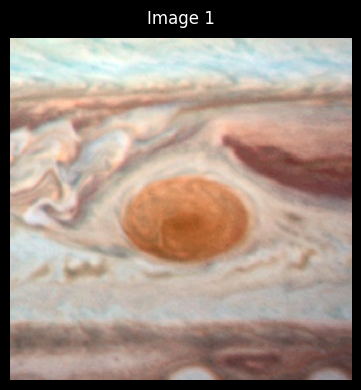

  📷 Image 1 - Caption: Using Hubble, astronomers regularly track Jupiter’s 
Great Red Spot, a giant swirling storm slightly larger 
than Earth. They found that the spot is shrinking 
and jiggling. Its outer winds are speeding up while 
moving significantly more slowly toward its center.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 2] ID: 2
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: Yes
📝 Query: What observational evidence from Hubble images supports the conclusion that the breakup of asteroid P/2013 R3 was not caused by a collision?

📄 TEXT CONTEXT:
[1] Asteroid P/2

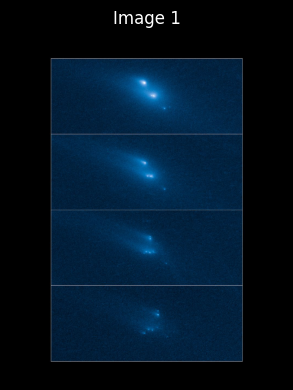

  📷 Image 1 - Caption: A Fragmented Asteroid Asteroid P/2013 R3
Asteroid P/2013 R3


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 3] ID: 3
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: No
📝 Query: How did multi-wavelength observations (ultraviolet, visible, infrared) allow Hubble to uncover hidden stages of star formation inside dense nebulae?

📄 TEXT CONTEXT:
[1] Exploring the Birth of Stars
Stars form in large clouds of gas and dust called 
nebulae that scatter the visible wavelengths of 
light our eyes can see. Hubble’s capability to see 
ultraviolet, visible, and nea

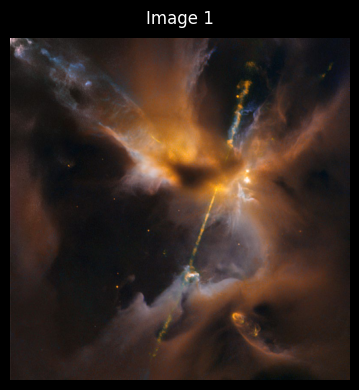

  📷 Image 1 - Caption: Hubble’s observations 
of nebulae reveal bizarre 
landscapes sculpted by 
radiation from young, 
exceptionally bright stars. 
The observations reveal 
the violent process of star 
birth that produces intense 
ultraviolet radiation and shock 
fronts. The radiation clears 
out cavities in stellar nursery 
clouds and erodes material 
from giant gas pillars that are 
incubators for fledgling stars. Jets Blasts from Young Stars HERBIG-HARO JET HH 24


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 4] ID: 4
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: Yes

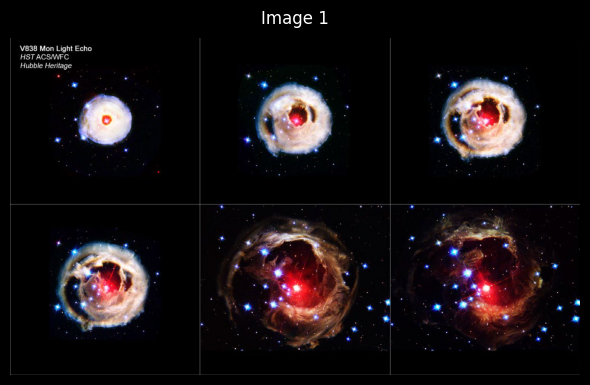

  📷 Image 1 - Caption: Expanding Light Echo of V838 Monocerotis


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 5] ID: 5
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: No
📝 Query: Explain how Hubble observations of Cepheid variable stars and Type Ia supernovae together strengthened the cosmic distance ladder.

📄 TEXT CONTEXT:
[1] Hubble observations, along 
with those of ground-based 
observatories, surprised 
astronomers by revealing 
that the universe is not just 
expanding but accelerating 
– a discovery that won the 
2011 Nobel Prize in Physics. 
Astronomers use stars 

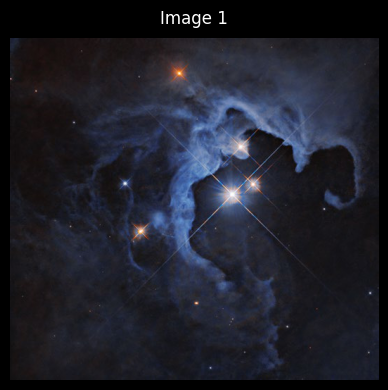

  📷 Image 1 - Caption: For more information about NASA’s Hubble Space Telescope 
mission and its discoveries, visit Hubble’s website at science.nasa.
gov/mission/hubble/.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 6] ID: 6
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: Yes
📝 Query: Which visual characteristics in Hubble images indicate the presence of gravitational lensing, and why are these features essential for studying very distant galaxies?

📄 TEXT CONTEXT:
[1] Focusing in on Gravitational Lenses
Gravity acts as a lens, magnifying and distorting space and time in

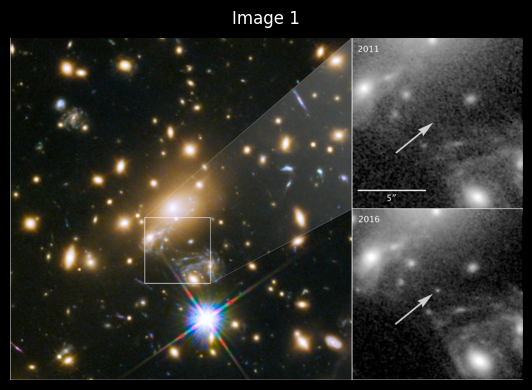

  📷 Image 1 - Caption: FOCUSING IN ON GRAVITATIONAL LENSES


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 7] ID: 7
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: No
📝 Query: How did Hubble’s observations of galaxy mergers change earlier assumptions that galaxies evolve in isolation?

📄 TEXT CONTEXT:
[1] Galaxy Details and Mergers
Astronomer Edwin Hubble pioneered the study of galaxies based 
simply on their appearance and categorized them according 
to three basic shapes: spiral, elliptical, and irregular. Some 60 
years later, the sharp vision of the space telescope name

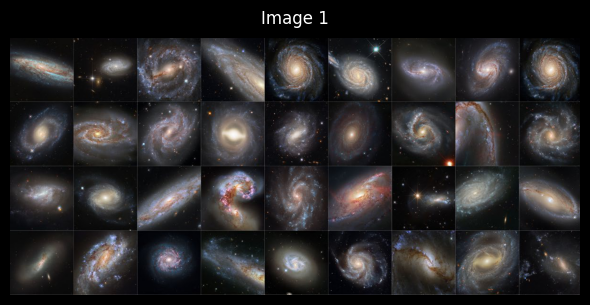

  📷 Image 1 - Caption: Supernova and Cepheid Variable Host Galaxies


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 8] ID: 8
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: Yes
📝 Query: What specific visual evidence from Hubble images supports the conclusion that supermassive black holes exist at the centers of most galaxies?

📄 TEXT CONTEXT:
[1] Monster Black Holes are Everywhere
Before Hubble, astronomers theorized the existence of 
supermassive black holes, but they had no conclusive evidence. 
Today we know that supermassive black holes lie at the heart of 
nearly every

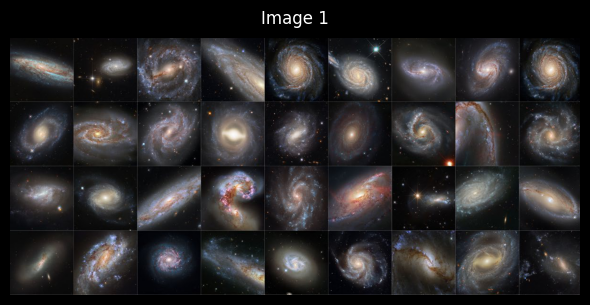

  📷 Image 1 - Caption: Supernova and Cepheid Variable Host Galaxies


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 9] ID: 9
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: No
📝 Query: Why are visually striking planetary nebula images scientifically important for understanding stellar death, even though they are not used for distance measurements?

📄 TEXT CONTEXT:
[1] When a medium-sized star begins to die, it sheds its outer layers, 
forming a shell of gas and dust called a “planetary nebula.” Before 
Hubble, ground-based images suggested that planetary nebulae 
have simpl

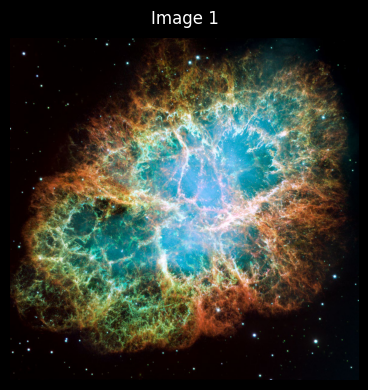

  📷 Image 1 - Caption: The Death Throes of Stars When a star runs out of its 
hydrogen fuel, the path it takes 
toward death depends on its 
size. For stars, it’s a balance 
between the radiation pressure 
of their fuel-burning cores 
pushing outward, and their gravity pulling inward. When 
stars run out of fuel, gravity 
wins this struggle, and the star 
begins to collapse into a black 
hole, supernova, neutron star, 
or white dwarf depending on 
its size.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 10] ID: 10
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Quer

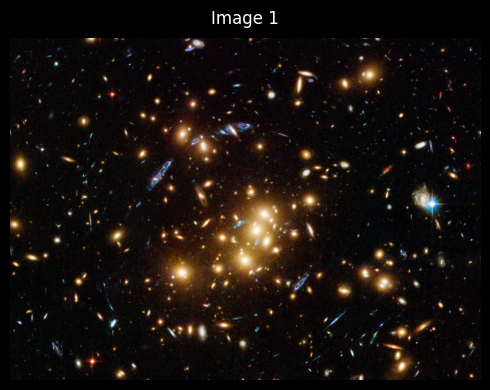

  📷 Image 1 - Caption: Galaxy Cluster + Dark Matter


----------------------------------------------------------------------------------------------------------------------------------------------------------------




In [25]:
display_formatted_results(retrieval_output, formatter)